In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\prathap\Desktop\Customer Intelligence & Automated Reporting Platform\customer-intelligence-platform"
)

sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT.exists())

True


In [2]:
from src.database import engine

print("Database engine imported successfully")

Database engine imported successfully


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.database import engine

query = """
SELECT *
FROM customer_rfm
"""

customer_rfm = pd.read_sql(
    query,
    engine
)

customer_rfm.head()

,customer_id,country,first_purchase_date,last_purchase_date,recency_days,frequency,monetary_value,average_order_value,unique_products,total_quantity,...,return_line_items,returned_quantity,returned_value,return_value_rate,customer_tenure_days,r_score,f_score,m_score,rfm_score,customer_segment
0,14095,United Kingdom,2009-12-17 12:49:00,2009-12-17 12:49:00,723,1,2.95,2.95,1,1.0,...,0,0.0,0.0,0.0,0,1,1,1,111,Lost / Inactive
1,13788,United Kingdom,2010-07-22 15:50:00,2010-07-22 15:50:00,506,1,3.75,3.75,1,1.0,...,0,0.0,0.0,0.0,0,1,1,1,111,Lost / Inactive
2,16738,United Kingdom,2011-02-15 09:46:00,2011-02-15 09:46:00,298,1,3.75,3.75,1,3.0,...,0,0.0,0.0,0.0,0,2,2,1,221,Lost / Inactive
3,14792,United Kingdom,2011-10-07 09:19:00,2011-10-07 09:19:00,64,1,6.20,6.20,2,2.0,...,0,0.0,0.0,0.0,0,3,1,1,311,Potential Loyalists
4,15913,United Kingdom,2010-06-23 16:31:00,2010-06-23 16:31:00,535,1,6.30,6.30,1,3.0,...,0,0.0,0.0,0.0,0,1,1,1,111,Lost / Inactive


In [4]:
segment_counts = (
    customer_rfm["customer_segment"]
    .value_counts()
)

segment_counts

customer_segment
Lost / Inactive        1644
Potential Loyalists    1464
Champions              1303
At Risk                 583
Loyal Customers         469
New / Promising         415
Name: count, dtype: int64

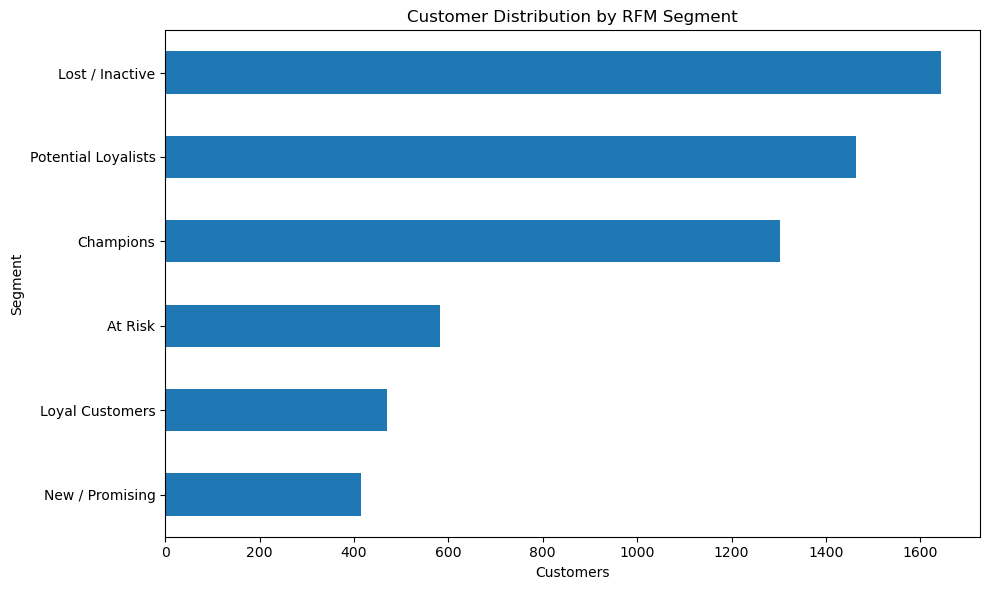

In [5]:
plt.figure(figsize=(10, 6))

segment_counts.sort_values().plot(
    kind="barh"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customers")
plt.ylabel("Segment")
plt.tight_layout()

plt.show()

In [6]:
segment_revenue = (
    customer_rfm
    .groupby("customer_segment")["monetary_value"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

customer_segment
Champions              11851276.88
Potential Loyalists     2398238.60
At Risk                 1466892.62
Lost / Inactive          725082.42
Loyal Customers          567590.56
New / Promising          365723.17
Name: monetary_value, dtype: float64

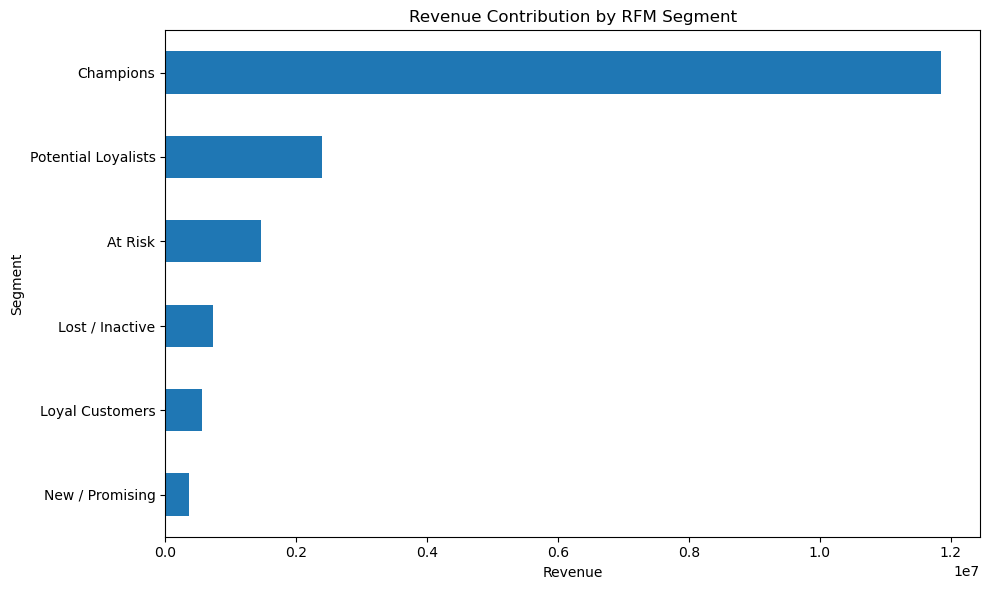

In [7]:
plt.figure(figsize=(10, 6))

segment_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Revenue")
plt.ylabel("Segment")
plt.tight_layout()

plt.show()